# Comparative Experiments

## Imports

In [1]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
os.environ["ENABLE_PJRT_COMPATIBILITY"] = "1"

from model import ClassicVAE, GMMVAE, VaDE
from train import ClassicVAE_trainer, GMMVAE_trainer, VaDE_trainer
from utils import image_to_jax1d, jax_collate_fn, plot_image

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
from flax import nnx
import optax
import pcax
import matplotlib.pyplot as plt

os.environ['JAX_PLATFORMS'] = 'cpu'

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
from matplotlib.lines import Line2D

## Training

In [3]:
train_dataset = MNIST(root="./../data", train=True, download=True, transform=image_to_jax1d)
test_dataset  = MNIST(root="./../data", train=False, download=True, transform=image_to_jax1d)

train_data_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=jax_collate_fn)
test_data_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=True, collate_fn=jax_collate_fn)

In [4]:
in_dim          = 28*28
latent_dim      = 16
hidden_dim      = 256
learning_rate   = 0.001
K               = 10
epochs_pretrain = 10   # Phase 1 — VAE warmup N(0,I) for GMM-VAE and VaDE
epochs_finetune = 100   # Phase 3 — full GMM / VaDE ELBO
epochs          = 100   # Models without pre-training (Conv VAE)


### Convolutional VAE

In [5]:
# model_conv     = ClassicVAE(in_dim=in_dim, latent_dim=latent_dim, hidden_dim=hidden_dim, rngs=nnx.Rngs(0), arch="conv")
# optimizer_conv = nnx.Optimizer(model_conv, optax.adam(learning_rate), wrt=nnx.Param)
# trainer_conv   = ClassicVAE_trainer(model_conv, optimizer_conv)

In [6]:
# train_history_conv, eval_history_conv = trainer_conv.train(epochs, train_data_loader, test_data_loader)

In [7]:
import orbax.checkpoint as ocp
from pathlib import Path

model_conv     = ClassicVAE(in_dim=in_dim, latent_dim=latent_dim, hidden_dim=hidden_dim, rngs=nnx.Rngs(0), arch="conv")
optimizer_conv = nnx.Optimizer(model_conv, optax.adam(learning_rate), wrt=nnx.Param)

checkpointer = ocp.StandardCheckpointer()
state        = nnx.state(model_conv, nnx.Param)
restored     = checkpointer.restore(Path("./../checkpoints/model_conv").resolve(), state)
nnx.update(model_conv, restored)
print("Conv VAE weights loaded from checkpoint.")

Conv VAE weights loaded from checkpoint.


### GMM VAE (learned prior)

In [8]:
model_gmm     = GMMVAE(in_dim=in_dim, latent_dim=latent_dim, hidden_dim=hidden_dim, K=K, rngs=nnx.Rngs(0))
optimizer_gmm = nnx.Optimizer(model_gmm, optax.adam(learning_rate), wrt=nnx.Param)
trainer_gmm   = GMMVAE_trainer(model_gmm, optimizer_gmm)

#### Phase 1 — Pré-entraînement VAE

In [9]:
pre_h_gmm, pre_eval_gmm = trainer_gmm.pretrain(
    epochs_pretrain, train_data_loader, test_data_loader
)

Pre-training (VAE warmup):   0%|          | 0/10 [00:00<?, ?it/s]

Pre-training (VAE warmup): 100%|██████████| 10/10 [05:04<00:00, 30.45s/it]


#### Phase 2 — Initialisation K-means

In [10]:
trainer_gmm.init_gmm_kmeans(train_data_loader)

K-means initialisation: encoding training set …


Running K-means with K=10 on 60000 points …
K-means done — cluster sizes: [2984, 8339, 3470, 8513, 6287, 6993, 5350, 6871, 6636, 4557]


array([5, 3, 7, ..., 2, 8, 2], shape=(60000,), dtype=int32)

#### Phase 3 — Fine-tuning GMM-VAE

In [11]:
train_history_gmm, eval_history_gmm = trainer_gmm.train(
    epochs_finetune, train_data_loader, test_data_loader
)

Fine-tuning (GMM-VAE): 100%|██████████| 100/100 [44:39<00:00, 26.80s/it]


### VaDE (learned prior)

In [12]:
model_vade     = VaDE(in_dim=in_dim, latent_dim=latent_dim, hidden_dim=hidden_dim, K=K, rngs=nnx.Rngs(0))
optimizer_vade = nnx.Optimizer(model_vade, optax.adam(learning_rate), wrt=nnx.Param)
trainer_vade   = VaDE_trainer(model_vade, optimizer_vade)

#### Phase 1 — Pré-entraînement VAE

In [13]:
pre_h_vade, pre_eval_vade = trainer_vade.pretrain(
    epochs_pretrain, train_data_loader, test_data_loader
)

Pre-training (VAE warmup): 100%|██████████| 10/10 [04:24<00:00, 26.44s/it]


#### Phase 2 — Initialisation K-means

In [14]:
trainer_vade.init_gmm_kmeans(train_data_loader)

K-means initialisation: encoding training set …


Running K-means with K=10 on 60000 points …
K-means done — cluster sizes: [7899, 8186, 3436, 7700, 4969, 2932, 4302, 6984, 6707, 6885]


array([2, 9, 0, ..., 7, 9, 0], shape=(60000,), dtype=int32)

#### Phase 3 — Fine-tuning VaDE

In [15]:
train_history_vade, eval_history_vade = trainer_vade.train(
    epochs_finetune, train_data_loader, test_data_loader
)

Fine-tuning (VaDE): 100%|██████████| 100/100 [42:19<00:00, 25.40s/it]


## Save Weights

In [17]:
import orbax.checkpoint as ocp
from pathlib import Path

ckpt_dir = Path("./../checkpoints")
ckpt_dir.mkdir(exist_ok=True)

checkpointer = ocp.StandardCheckpointer()

models_to_save = {
    "model_conv": model_conv,
    "model_gmm":  model_gmm,
    "model_vade": model_vade,
}

for name, model in models_to_save.items():
    state = nnx.state(model, nnx.Param)
    checkpointer.save(ckpt_dir / name, state, force=True)

checkpointer.wait_until_finished()
print(f"All models saved to {ckpt_dir.resolve()}")


ERROR:absl:[process=0][thread=serialize_shardings][operation_id=2] _SignalingThread.run() raised an exception: Error parsing object member "kvstore": Invalid file path: "../checkpoints/model_conv.orbax-checkpoint-tmp/_sharding" [source locations='tensorstore/internal/json_binding/json_binding.h:830\ntensorstore/internal/json_binding/json_binding.h:873\ntensorstore/internal/json_binding/json_binding.h:830']
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/orbax/checkpoint/_src/futures/future.py", line 347, in run
    super().run()
  File "/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/orbax/checkpoint/_src/futures/future.py", line 309, in _target_setting_result
    self._result = target()
                   ^^^^^^^^
  File "/opt/homebrew/anaconda3/e

ValueError: Error parsing object member "kvstore": Invalid file path: "../checkpoints/model_conv.orbax-checkpoint-tmp/_sharding" [source locations='tensorstore/internal/json_binding/json_binding.h:830\ntensorstore/internal/json_binding/json_binding.h:873\ntensorstore/internal/json_binding/json_binding.h:830']

## Image Reconstruction

In [37]:
x_orig = next(iter(train_data_loader))[0][:5]
keys   = jr.split(jr.PRNGKey(1), 5)

x_rec_conv = jax.vmap(lambda xi, k: model_conv(xi, k))(x_orig, keys)
x_rec_gmm  = jax.vmap(lambda xi, k: model_gmm(xi, k))(x_orig, keys)
x_rec_vade = jax.vmap(lambda xi, k: model_vade(xi, k))(x_orig, keys)


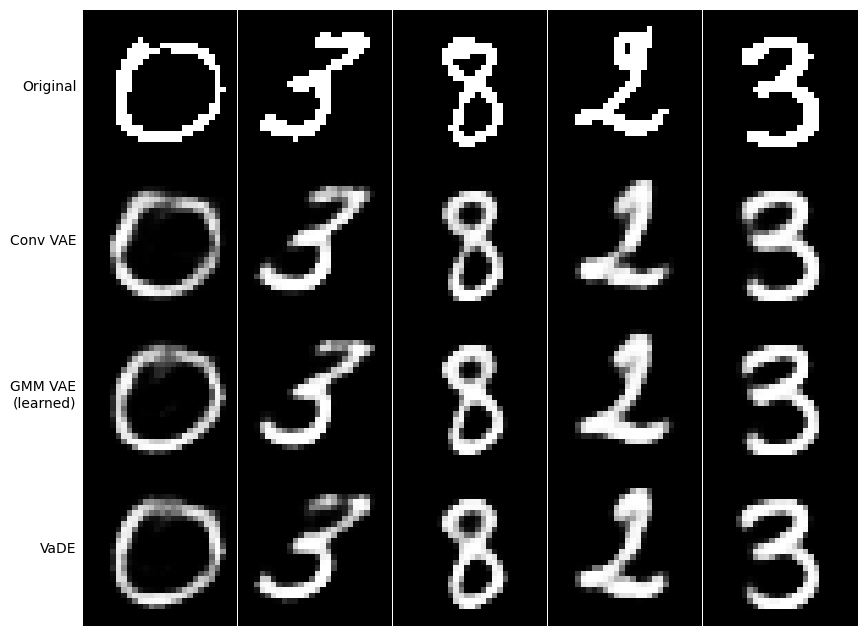

In [38]:
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.subplots_adjust(wspace=0, hspace=0)

row_labels = ["Original", "Conv VAE", "GMM VAE\n(learned)", "VaDE"]
rows       = [x_orig, x_rec_conv, x_rec_gmm, x_rec_vade]

for row_idx, (label, row_data) in enumerate(zip(row_labels, rows)):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        plot_image(row_data[col_idx], ax=ax)
        ax.axis("off")
    axes[row_idx, 0].text(
        -0.04, 0.5, label,
        transform=axes[row_idx, 0].transAxes,
        fontsize=10, va="center", ha="right",
    )

plt.show()


## Image Generation

In [41]:
gen_keys = jr.split(jr.PRNGKey(5), 5)

gen_conv = jnp.stack([model_conv.generate_mean(k) for k in gen_keys])
gen_gmm  = jnp.stack([model_gmm.generate_mean(k)  for k in gen_keys])
gen_vade = jnp.stack([model_vade.generate_mean(k)  for k in gen_keys])


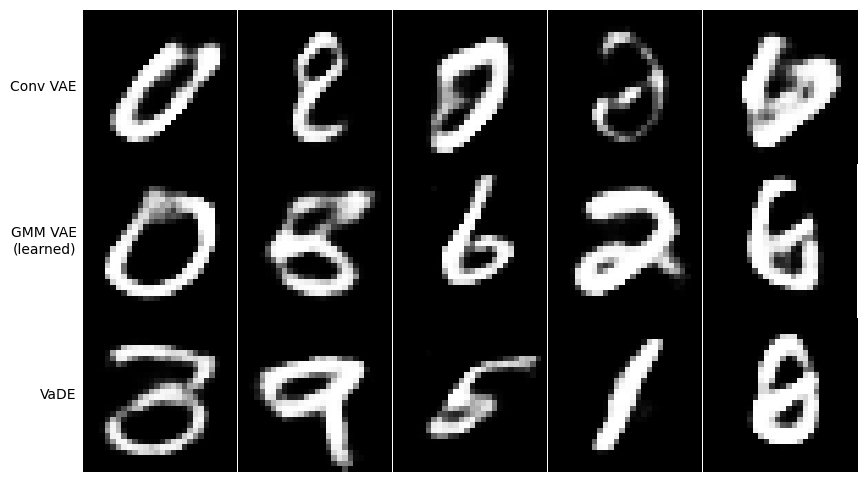

In [42]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
fig.subplots_adjust(wspace=0, hspace=0)

row_labels = ["Conv VAE", "GMM VAE\n(learned)", "VaDE"]
rows       = [gen_conv, gen_gmm, gen_vade]

for row_idx, (label, row_data) in enumerate(zip(row_labels, rows)):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        plot_image(row_data[col_idx], ax=ax)
        ax.axis("off")
    axes[row_idx, 0].text(
        -0.04, 0.5, label,
        transform=axes[row_idx, 0].transAxes,
        fontsize=10, va="center", ha="right",
    )

plt.show()


## Latent Space Visualization

In [22]:
x_all      = jnp.concatenate([batch[0] for batch in train_data_loader], axis=0)
labels_all = jnp.concatenate([batch[1] for batch in train_data_loader], axis=0)
keys_all   = jr.split(jr.PRNGKey(0), x_all.shape[0])

In [23]:
N_SCATTER = 3000

def make_df(z_pca, labels, n=N_SCATTER, seed=42):
    np.random.seed(seed)
    idx = np.random.choice(len(z_pca), size=n, replace=False)
    return pd.DataFrame({
        "PCA 1": np.array(z_pca[idx, 0]),
        "PCA 2": np.array(z_pca[idx, 1]),
        "Digit": np.array(labels[idx]).astype(str),
    })

def pca_inverse(z, z_pca):
    """Recover the PCA projection matrix V and the data mean."""
    z_np     = np.array(z)
    z_pca_np = np.array(z_pca)
    z_mean   = z_np.mean(axis=0)
    V, _, _, _ = np.linalg.lstsq(z_np - z_mean, z_pca_np, rcond=None)  # (latent_dim, 2)
    return z_mean, V

def build_grid(df):
    """Build a 2D meshgrid covering the scatter plot extent."""
    x_min, x_max = df["PCA 1"].min(), df["PCA 1"].max()
    y_min, y_max = df["PCA 2"].min(), df["PCA 2"].max()
    mx, my = (x_max - x_min) * 0.05, (y_max - y_min) * 0.05
    xx, yy = np.meshgrid(
        np.linspace(x_min - mx, x_max + mx, 100),
        np.linspace(y_min - my, y_max + my, 100),
    )
    return xx, yy

### PCA

In [24]:
z_conv     = jax.vmap(model_conv.encode)(x_all, keys_all)
state_conv = pcax.fit(z_conv, n_components=2)
z_conv_pca = pcax.transform(state_conv, z_conv)

In [25]:
z_gmm     = jax.vmap(model_gmm.encode)(x_all, keys_all)
state_gmm = pcax.fit(z_gmm, n_components=2)
z_gmm_pca = pcax.transform(state_gmm, z_gmm)

In [26]:
z_vade     = jax.vmap(model_vade.encode)(x_all, keys_all)
state_vade = pcax.fit(z_vade, n_components=2)
z_vade_pca = pcax.transform(state_vade, z_vade)

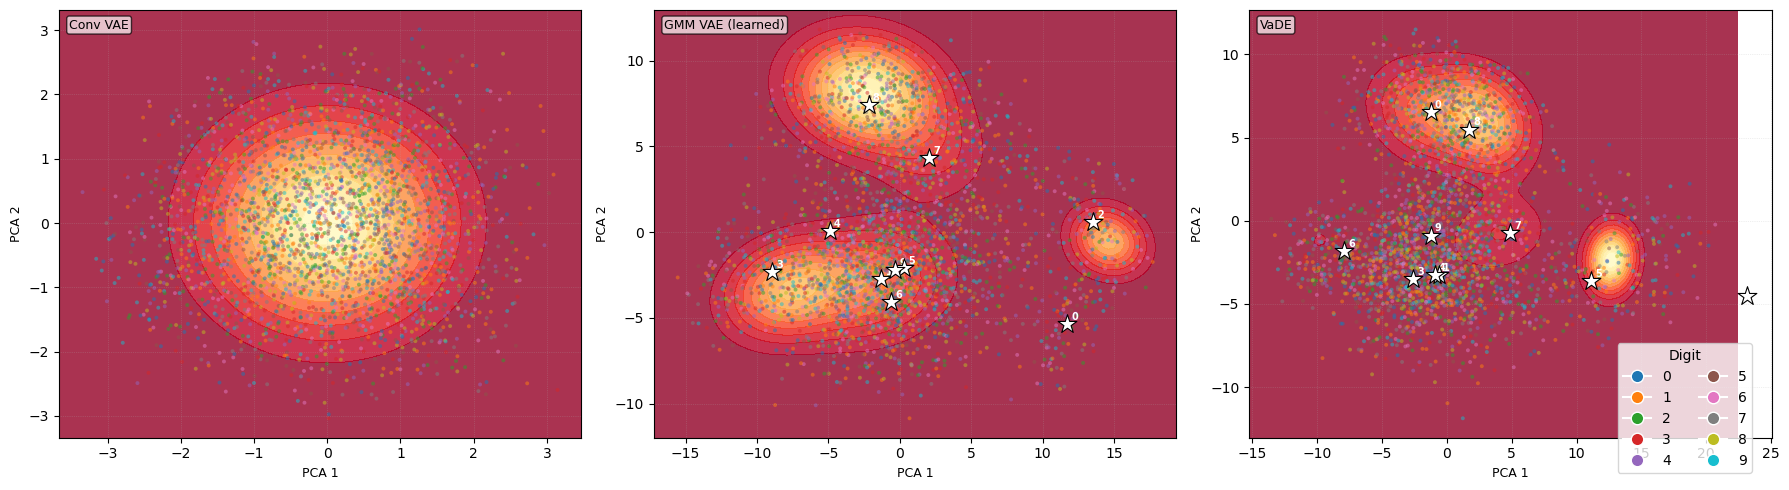

In [27]:
palette     = sns.color_palette("tab10", 10)
prior_gauss = multivariate_normal(mean=[0, 0], cov=np.eye(2))

def _scatter(ax, df, x_col="PCA 1", y_col="PCA 2"):
    sns.scatterplot(
        data=df, x=x_col, y=y_col, hue="Digit",
        palette=palette, alpha=0.5, s=8, linewidth=0,
        hue_order=[str(i) for i in range(10)], ax=ax, legend=False,
    )

def _style(ax, label, x_col="PCA 1", y_col="PCA 2"):
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
    ax.text(0.02, 0.98, label, transform=ax.transAxes, fontsize=9,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

def _plot_gaussian_pca(ax, z_pca, label):
    df = make_df(z_pca, labels_all)
    xx, yy = build_grid(df)
    zz = prior_gauss.pdf(np.stack([xx, yy], axis=-1))
    ax.contourf(xx, yy, zz, levels=12, cmap="YlOrRd_r", alpha=0.8)
    _scatter(ax, df)
    _style(ax, label)

def _plot_gmm_pca(ax, model, z, z_pca, label):
    df = make_df(z_pca, labels_all)
    z_mean, V = pca_inverse(z, z_pca)
    xx, yy   = build_grid(df)
    grid_2d     = np.stack([xx.ravel(), yy.ravel()], axis=1)
    grid_latent = jnp.array(z_mean + grid_2d @ V.T)
    zz          = np.array(jax.vmap(model.prior_pdf)(grid_latent)).reshape(xx.shape)
    mu_pca      = (np.array(model.mu_gmm.get_value()) - z_mean) @ V
    ax.contourf(xx, yy, zz, levels=12, cmap="YlOrRd_r", alpha=0.8)
    _scatter(ax, df)
    ax.scatter(
        mu_pca[:, 0], mu_pca[:, 1],
        marker="*", s=200, c="white", edgecolors="black", linewidths=0.8, zorder=5,
    )
    for k in range(len(mu_pca)):
        ax.annotate(str(k), xy=(mu_pca[k, 0], mu_pca[k, 1]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=7, color="white", fontweight="bold")
    _style(ax, label)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_plot_gaussian_pca(axes[0], z_conv_pca, "Conv VAE")
_plot_gmm_pca(axes[1], model_gmm,  z_gmm,  z_gmm_pca,  "GMM VAE (learned)")
_plot_gmm_pca(axes[2], model_vade, z_vade, z_vade_pca, "VaDE")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[i], markersize=9, label=str(i))
    for i in range(10)
]
fig.legend(handles=legend_elements, title="Digit",
           loc="lower right", bbox_to_anchor=(0.98, 0.03),
           fontsize=10, ncol=2)

fig.tight_layout()
plt.show()


### UMAP

In [28]:
from umap import UMAP as UMAP_reducer

N_UMAP      = 5000
UMAP_PARAMS = dict(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

def umap_embed(z, seed=42, n=N_UMAP):
    """Subsample z, fit UMAP, return (reducer, z_2d, idx)."""
    np.random.seed(seed)
    idx     = np.random.choice(len(z), size=n, replace=False)
    reducer = UMAP_reducer(**UMAP_PARAMS)
    z_2d    = reducer.fit_transform(np.array(z[idx]))
    return reducer, z_2d, idx

/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
reducer_conv, z_conv_umap, umap_idx_conv = umap_embed(z_conv)

/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [30]:
reducer_gmm, z_gmm_umap, umap_idx_gmm = umap_embed(z_gmm)

/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [31]:
reducer_vade, z_vade_umap, umap_idx_vade = umap_embed(z_vade)

/opt/homebrew/anaconda3/envs/aria_fondements/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


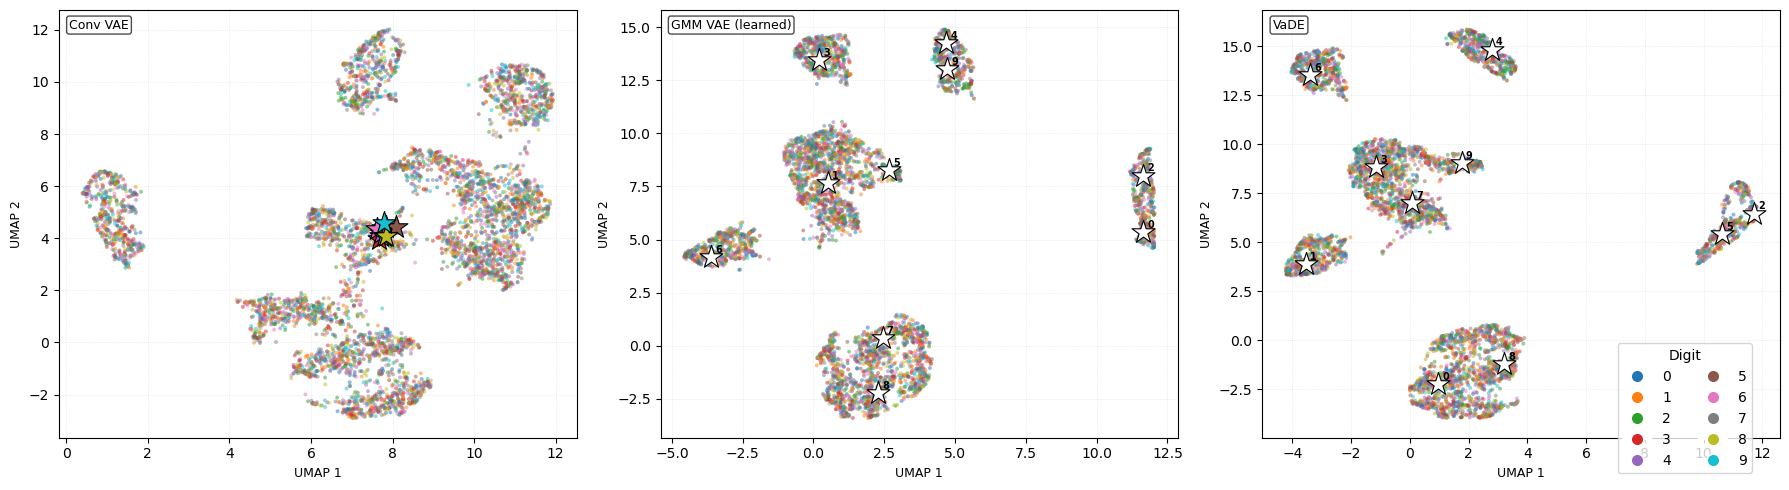

In [32]:
def _make_df_umap(z_2d, idx):
    return pd.DataFrame({
        "UMAP 1": z_2d[:, 0],
        "UMAP 2": z_2d[:, 1],
        "Digit":  np.array(labels_all[idx]).astype(str),
    })

def _plot_gaussian_umap(ax, z_2d, idx, label):
    df = _make_df_umap(z_2d, idx)
    _scatter(ax, df, x_col="UMAP 1", y_col="UMAP 2")
    digit_arr = np.array(labels_all[idx])
    for d in range(10):
        mask = digit_arr == d
        if mask.sum() > 0:
            cx, cy = z_2d[mask, 0].mean(), z_2d[mask, 1].mean()
            ax.scatter(cx, cy, marker="*", s=300,
                       c=[palette[d]], edgecolors="black", linewidths=0.8, zorder=5)
    _style(ax, label, x_col="UMAP 1", y_col="UMAP 2")

def _plot_gmm_umap(ax, model, z_2d, idx, reducer, label):
    df = _make_df_umap(z_2d, idx)
    _scatter(ax, df, x_col="UMAP 1", y_col="UMAP 2")
    mu      = np.array(model.mu_gmm.get_value())
    mu_umap = reducer.transform(mu)
    ax.scatter(
        mu_umap[:, 0], mu_umap[:, 1],
        marker="*", s=300, c="white", edgecolors="black", linewidths=0.8, zorder=5,
    )
    for k in range(len(mu_umap)):
        ax.annotate(str(k), xy=(mu_umap[k, 0], mu_umap[k, 1]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=7, color="black", fontweight="bold")
    _style(ax, label, x_col="UMAP 1", y_col="UMAP 2")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_plot_gaussian_umap(axes[0], z_conv_umap, umap_idx_conv, "Conv VAE")
_plot_gmm_umap(axes[1], model_gmm,  z_gmm_umap,  umap_idx_gmm,  reducer_gmm,  "GMM VAE (learned)")
_plot_gmm_umap(axes[2], model_vade, z_vade_umap, umap_idx_vade, reducer_vade, "VaDE")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[i], markersize=9, label=str(i))
    for i in range(10)
]
fig.legend(handles=legend_elements, title="Digit",
           loc="lower right", bbox_to_anchor=(0.98, 0.03),
           fontsize=10, ncol=2)

fig.tight_layout()
plt.show()
